In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba_array
from mpl_toolkits.mplot3d import Axes3D
from transformers import LlamaForCausalLM, LlamaTokenizer,AutoTokenizer, AutoModelForCausalLM
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# 加载模型和分词器
def load_model_and_tokenizer(model_name, device):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token  # 设置 eos_token 为 pad_token
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16).to(device)
    model.eval()
    return model, tokenizer

# 运行推理并获取激活值和权重
@torch.no_grad()
def get_activations_and_weights(model, tokenizer, texts, layer_index = 4, channel_indexs = 200, device="cpu"):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    print("outputs.hidden_states shape is ", len(outputs.hidden_states))
    
    activation = outputs.hidden_states[layer_index].abs()[:, :, :channel_indexs]  # 最后一层激活值，选择前100个token和通道
    q_weight = model.model.layers[layer_index].self_attn.q_proj.weight.abs()[:, :channel_indexs]  # 第 layer_index 层的 q 映射层权重的前 200 个通道
    k_weight = model.model.layers[layer_index].self_attn.k_proj.weight.abs()[:, :channel_indexs]  # 第 layer_index 层的 q 映射层权重
    v_weight = model.model.layers[layer_index].self_attn.v_proj.weight.abs()[:, :channel_indexs]  # 第 layer_index 层的 q 映射层权重
    fcs = [q_weight,k_weight, v_weight]
    
    print(f"activation shape is {activation.shape} self_attn.q_proj.weight shape is {fcs[0].shape}")
    return activation, fcs

# 计算 SmoothQuant 的缩放因子
@torch.no_grad()
def calculate_scales(activation, fcs, alpha=0.5):
    original_shape = activation.shape
    act_reshaped = activation.view(-1, original_shape[-1]).abs().detach() # 将激活张量 shape 转换成 [batch_size * seq_len, hidden_size]
    act_max = torch.max(act_reshaped, dim=0)[0].float().cpu()  # 计算每个隐藏维度上的最大值并转移到 CPU
    
    # 如果 fcs 是线性层列表，则取整体的最大值，用来计算平滑因子 scales。
    weight_max_list = torch.cat([fc.abs().max(dim=0, keepdim=True)[0] for fc in fcs], dim=0)
    w_max = weight_max_list.max(dim=0)[0].clamp(min=1e-5).cpu()  # 计算所有权重的最大值并转移到 CPU

    print(f"act_max shape is {act_max.shape}, w_max shape is {w_max.shape}")
    scales = act_max.pow(alpha) / w_max.pow(1 - alpha)
    print(f"scales shape is {scales.shape}")
    return scales

# 应用 SmoothQuant 缩放因子到激活值和权重
@torch.no_grad()
def apply_smoothquant_scaling(activation, weights, scales):
    smooth_activation = activation.cpu() / scales.view(1, 1, -1)
    q_proj_weight = weights[0].cpu()
    smooth_q_weight = q_proj_weight * scales.view(1, -1)
    print(f"smooth_activation_sample shape is {smooth_activation.shape} q_proj smooth_weight shape is {smooth_q_weight.shape}")

    return smooth_activation, smooth_q_weight

# 检测离群值并打印通道索引
def find_outlier_channels(activation_sample, threshold=10):
    mean = activation_sample.mean(dim=(0, 1))
    std = activation_sample.std(dim=(0, 1))
    z_scores = (activation_sample - mean) / std

    outliers = torch.where(z_scores > threshold)
    unique_channels = torch.unique(outliers[2])
    print(f"离群值所在的通道索引: {unique_channels.tolist()}")

# 3D 绘图函数
def plot_3d(data, title, xlabel, ylabel, zlabel, color, ax, y_max):
    x, y = np.meshgrid(np.arange(data.shape[1]), np.arange(data.shape[0]))
    x, y = x.flatten(), y.flatten()
    z = np.zeros_like(x)
    dx = dy = 1
    dz = data.flatten()
    ax.bar3d(x, y, z, dx, dy, dz, color=color, zsort='average')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_zlim(0, y_max)  # 设置统一的 y 轴范围

# 主函数，执行各个步骤
def main():
    # model_name = "/home/ubuntu/data/exp/proj2410/model/Llama2-7B"
    model_name = "/home/ubuntu/data/exp/proj2410/model/Qwen2.5-3B"
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, tokenizer = load_model_and_tokenizer(model_name, device)
    
    # 处理输入文本并获取激活值和权重
    input_texts = [
        "The quick brown fox jumps over the lazy dog. " * 2,  # 通过重复句子生成超过64个词的文本
        "Artificial intelligence is revolutionizing the world. " * 4,
        "Large language models are powerful tools for NLP tasks. " * 2,
        "The meaning of life is to find " 
    ]
    activation_sample, weight_sample = get_activations_and_weights(model, tokenizer,
                                                                    input_texts, layer_index = 4,
                                                                    channel_indexs=200, device=device)

    # 检查离群值所在通道
    find_outlier_channels(activation_sample)

    # 计算 SmoothQuant 缩放因子并应用平滑转换
    scales = calculate_scales(activation_sample, weight_sample)

    smooth_activation_sample, smooth_weight_sample = apply_smoothquant_scaling(activation_sample, weight_sample, scales)

    # 确定所有图的统一 y 轴范围
    y_max = max(
        np.max(activation_sample.cpu().numpy()),
        np.max(smooth_activation_sample.cpu().numpy()),
        np.max(weight_sample[0].cpu().numpy()),
        np.max(smooth_weight_sample.cpu().numpy())
    )
    
    # 创建图表
    fig = plt.figure(figsize=(8, 8))
    batch_size, seq_len, hidden_size = activation_sample.shape
    activation_sample = activation_sample.view(-1, hidden_size)
    smooth_activation_sample = smooth_activation_sample.view(-1, hidden_size)
    
    # 绘制原始和平滑后的激活值和权重, weight_sample 是 q、k、v 映射层权重组合的列表
    plot_titles = [
        ("Activation (Original)\nHard to quantize", activation_sample, "blue"),
        # ("Activation (SmoothQuant)\nEasy to quantize", smooth_activation_sample, "blue"),
        # ("Weight (Original)\nVery easy to quantize", weight_sample[0], "blue"),
        # ("Weight (SmoothQuant)\nHarder but still easy to quantize", smooth_weight_sample, "blue")
    ]
    
    # for i, (title, data, color) in enumerate(plot_titles, start=1):
    #     ax = fig.add_subplot(1, 4, i, projection='3d')
    #     xlabel = "Channel" if "Activation" in title else "In Channel"
    #     ylabel = "Token" if "Activation" in title else "Out Channel"
    #     plot_3d(data.detach().cpu().numpy(), title, xlabel, ylabel, "Absolute Value", color, ax, y_max)
    
    # 仅绘制一个大于均值+3sigma的值设置为粉红色，其余值设置为淡绿色的效果
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    xlabel = "Channel"
    ylabel = "Token"
    activation_sample = activation_sample.detach().cpu().numpy()
    # 计算均值和标准差
    mean_value = np.mean(activation_sample)
    std_value = np.std(activation_sample)
    # 设置阈值
    threshold = mean_value + 3 * std_value
    # 生成颜色数组
    colors = np.where(activation_sample > threshold, 'red', '#41B683').flatten()
    # 将颜色名称转换为 RGBA 格式
    colors_rgba = to_rgba_array(colors)
    plot_3d(activation_sample, "Activation (fp16)\nQwen2.5-3B", xlabel, ylabel, "Absolute Value", colors_rgba, ax, y_max)
    ####################################

    # 添加主标题并保存图表
    fig.suptitle("SmoothQuant Visualization", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.savefig("llama2_7b_smoothquant_visualization2.png", format='png', dpi=300)
    plt.close()

if __name__ == "__main__":
    main()


/home/ubuntu/miniconda3/envs/quant/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.02s/it]
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
/home/ubuntu/miniconda3/envs/quant/lib/python3.11/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


outputs.hidden_states shape is  37
activation shape is torch.Size([4, 34, 200]) self_attn.q_proj.weight shape is torch.Size([2048, 200])
离群值所在的通道索引: []
act_max shape is torch.Size([200]), w_max shape is torch.Size([200])
scales shape is torch.Size([200])
smooth_activation_sample shape is torch.Size([4, 34, 200]) q_proj smooth_weight shape is torch.Size([2048, 200])


Llama3-8B with grad clip 0.3
wlr 2e-5 lr 1e-4
g2 w2 13.54 c4 17.38 
g2-graual w2 14.77 18.21
wlr 1e-4 lr 1e-4
g2 w2  14.23 18.16
g2-graual  36.19 32.99 # ?见鬼了模型差异性怎么这么大? Llama3-8B和Llama2-7B的不同性有点离谱了
wlr 2e-4 lr 1e-4
g2 w2 
g2-graual 
wlr 1e-3 lr 1e-4
g2 w2 
g2-graual 
wlr 2e-3 lr 1e-4
g2 w2 
g2-graual 
wlr 1e-2 lr 1e-4
g2 w2 
g2-graual 



In [3]:
import torch


a = torch.randn(3, 4)
_,topk = torch.topk(a, 2, dim=1)
# shape of topk is (**shape, topk_num)
print(a,topk)
print(topk.sort().values)
print(a[])

tensor([[-2.4480,  0.1536, -1.3702,  1.0732],
        [ 1.1995,  1.5418,  0.7724, -0.3548],
        [ 0.5699,  0.1097,  0.3368, -1.1408]]) tensor([[3, 1],
        [1, 0],
        [0, 2]])
tensor([[1, 3],
        [0, 1],
        [0, 2]])


In [ ]:
# 在滑动窗口前选择 hh_size 个 token
#  将选取的内容改为[:, reserved_len:seq_len-recent_size] 注意reserved_len<=seq_len-recent_size
select_hh_scores = self.hh_score[:, reserved_len:seq_len - self.recent_size]
_, keep_topk = torch.topk(select_hh_scores, self.hh_size, dim=-1)
# 把排除的部分加回来
keep_topk = keep_topk + reserved_len
keep_topk = keep_topk.sort().values

# i = 5
# for ii in range(i):
#     keep_topk[:, ii] = ii

# pdb.set_trace()

# 选择滑动窗口内的 token
# keep_recent = torch.arange(seq_len - self.recent_size, seq_len).expand(keep_topk.shape[0], 1).to(keep_topk.device)
keep_recent = torch.arange(seq_len - self.recent_size, seq_len, device=keep_topk.device).repeat(keep_topk.shape[0], 1)
keep_idx = torch.cat([keep_topk, keep_recent], dim=-1)

i = 0
keep_i_past_k_token = past_key_values[0][:, :, : i, :]
keep_i_past_v_token = past_key_values[1][:, :, : i, :]
keep_i_hh_token = self.hh_score[:, : i]
# print(i)

mask = torch.zeros(self.hh_score.shape, dtype=torch.bool).to(past_key_values[0].device)
mask = mask.scatter(-1, keep_idx, 1)

# kv缓存的形状是[bsz, num_heads, seq_len, head_dim]
k_hh_recent = past_key_values[0].squeeze()[mask].view(bsz, num_heads, -1, head_dim)
v_hh_recent = past_key_values[1].squeeze()[mask].view(bsz, num_heads, -1, head_dim)

k_hh_recent = torch.cat([keep_i_past_k_token, k_hh_recent], dim=2)
v_hh_recent = torch.cat([keep_i_past_v_token, v_hh_recent], dim=2)

self.hh_score= self.hh_score[mask].view(num_heads, self.cache_size)
self.hh_score = torch.cat([keep_i_hh_token, self.hh_score], dim=1)

# self.cache_size -= count

return (k_hh_recent, v_hh_recent

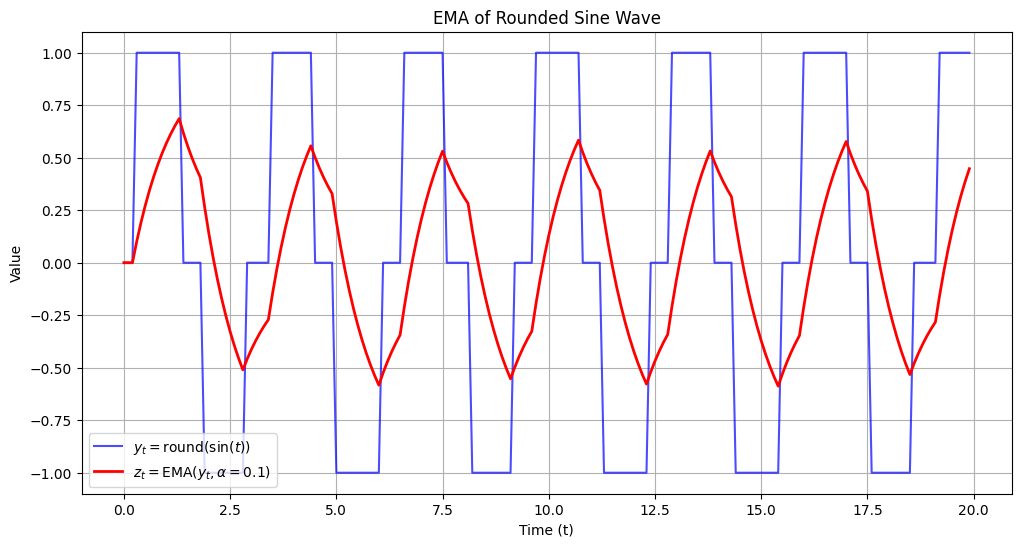

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 参数设置
alpha = 0.1  # 平滑系数
t_max = 20   # 最大时间范围
dt = 0.1    # 时间步长

# 时间序列
t = np.arange(0, t_max, dt)

# 输入信号 y_t = round(sin(t))
y = np.round(np.sin(2*t))

# EMA 计算
z = np.zeros_like(y)  # 初始化 EMA 数组
z[0] = y[0]           # 初始值为第一个输入信号的值
for i in range(1, len(t)):
    z[i] = alpha * y[i] + (1 - alpha) * z[i-1]
z = np.round(z)  # 取整
# 绘图
plt.figure(figsize=(12, 6))
plt.plot(t, y, label=r"$y_t = \text{round}(\sin(t))$", color="blue", alpha=0.7)
plt.plot(t, z, label=r"$z_t = \text{EMA}(y_t, \alpha=0.1)$", color="red", linewidth=2)
plt.title("EMA of Rounded Sine Wave")
plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()